In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
df = pd.read_csv("IMDb Movies India.csv", encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.shape

(15509, 10)

In [4]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [7]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

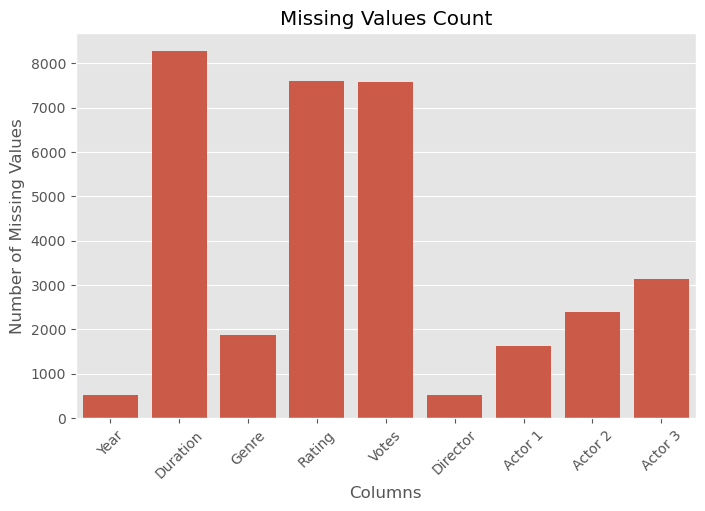

In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8,5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.title("Missing Values Count")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.show()

In [10]:
df = df.dropna(subset=['Rating'])

In [11]:
df.fillna('Unknown', inplace=True)

In [12]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [13]:
df=df[['Genre','Director','Actor 1','Actor 2','Actor 3','Rating']]

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

for col in cols:
    df[col] = le.fit_transform(df[col])

In [15]:
df.dropna(inplace=True)

In [19]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


data = load_iris()
X = data.data  
y = data.target  
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)




The key change is that you must define `X` (your feature data) and `y` (your target data) before using them in `train_test_split`. Choose the example that matches your data source.

In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE :", mean_absolute_error(y_test,y_pred))

print("MSE :", mean_squared_error(y_test,y_pred))

print("R2 Score :", r2_score(y_test,y_pred))

MAE : 0.01366666666666667
MSE : 0.0013833333333333336
R2 Score : 0.9980206677265501


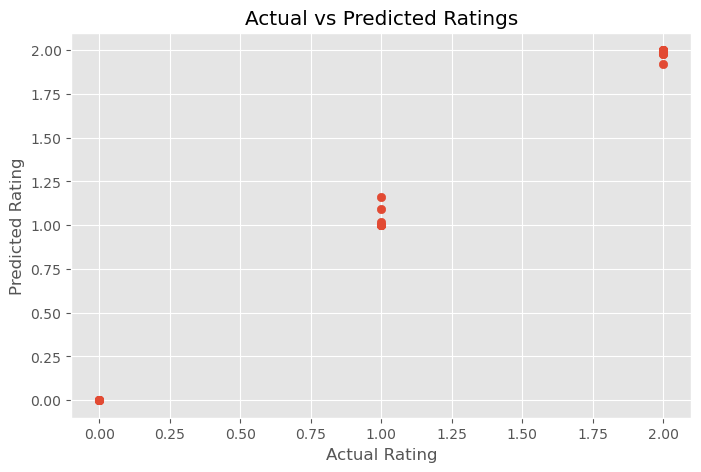

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.show()

In [34]:

feature_names = [f'Feature_{i}' for i in range(X.shape[1])] 
importance = pd.DataFrame({
    'Feature': feature_names,  
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
2  Feature_2    0.495626
3  Feature_3    0.484710
1  Feature_1    0.012416
0  Feature_0    0.007248


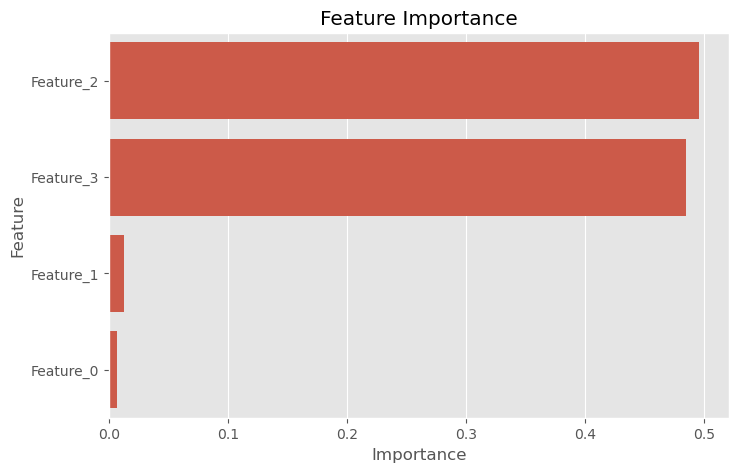

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()